In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize

In [ ]:
# Load the pre-trained Xception model without the top layer
xception_base_model = Xception(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))

# Add custom layers on top of the base model
x = xception_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
xception_predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Define the complete Xception model
xception_model = Model(inputs=xception_base_model.input, outputs=xception_predictions)

# Freeze the base model layers to prevent them from being trained initially
for layer in xception_base_model.layers:
    layer.trainable = False

# Compile the Xception model
xception_model.compile(optimizer=Adam(learning_rate=0.000001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Optionally, print the model summary
xception_model.summary()

# Define callbacks for Xception training (you can reuse the CSVLogger and checkpoint or define new ones)
xception_checkpoint_cb = ModelCheckpoint(
    filepath='/kaggle/working/Xception_best_Weights.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=2
)
# You can reuse the same csv_logger if you wish or create a new one:
xception_csv_logger = CSVLogger('xception_training_log.csv', separator=',', append=False)

# Train the Xception model (here we use 50 epochs; adjust as needed)
history_xception = xception_model.fit(train_ds, validation_data=val_ds, epochs=50,
                                      callbacks=[xception_checkpoint_cb, xception_csv_logger])

# Evaluate the Xception model
xception_loss, xception_accuracy = xception_model.evaluate(val_ds)
print(f"Xception Accuracy: {xception_accuracy * 100:.2f}%")

# (Optional) Save the Xception model weights and architecture
xception_model.save_weights('/kaggle/working/Xception_final_model.weights.h5')
xception_model.save('/kaggle/working/Xception_final_model.h5')

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 23,486,508 (89.59 MB)

 Trainable params: 2,625,028 (10.01 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2464 - loss: 3.1216
Epoch 1: val_accuracy improved from -inf to 0.33958, saving model to /kaggle/working/Xception_best_Weights.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.2466 - loss: 3.1188 - val_accuracy: 0.3396 - val_loss: 1.5487
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3743 - loss: 1.4385
Epoch 2: val_accuracy improved from 0.33958 to 0.46354, saving model to /kaggle/working/Xception_best_Weights.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - accuracy: 0.3745 - loss: 1.4381 - val_accuracy: 0.4635 - val_loss: 1.2287
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4775 - loss: 1.1921
Epoch 3: val_accuracy improved from 0.46354 to 0.52778, saving model to /kaggle/working/Xception_best_Weights.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - accuracy: 0.4776 - loss: 1.1919 - val_accuracy: 0.5278 - val_loss: 1.0886
Epoch 4/50
240/240 ━━

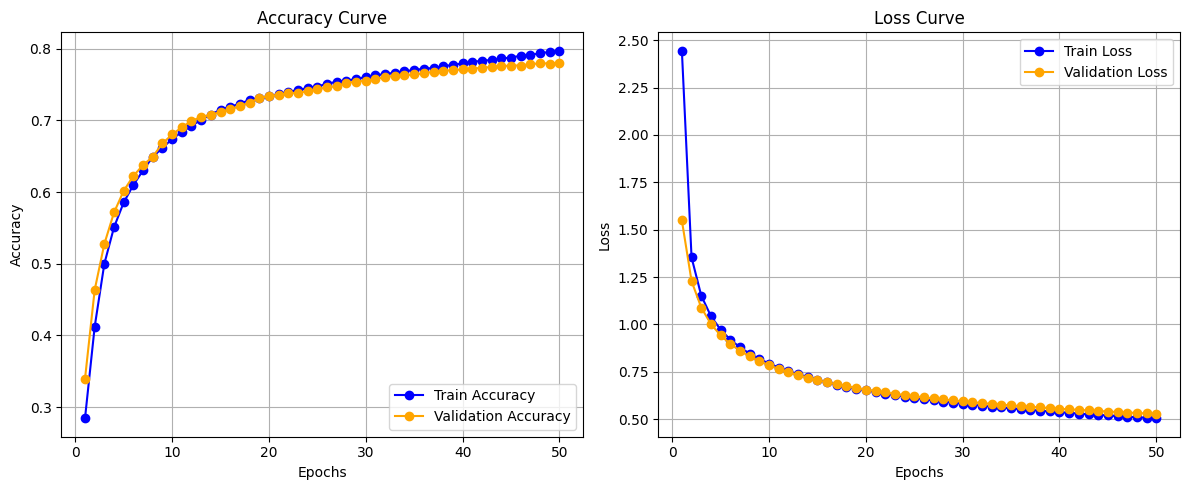

In [ ]:
# Define epoch range
epochs_range = range(1, len(history_xception.history['accuracy']) + 1)

# Create a side-by-side layout for accuracy and loss
plt.figure(figsize=(12, 5))  # Adjust the figure size for better layout

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_xception.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs_range, history_xception.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.grid()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_xception.history['loss'], label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, history_xception.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.grid()

# Adjust layout for readability
plt.tight_layout()

# Save the figure with high resolution (DPI)
plt.savefig('/kaggle/working/xception_model_accuracy_loss.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

In [ ]:
# Load best model weights before evaluation
xception_model.load_weights('/kaggle/working/Xception_best_Weights.weights.h5')

In [ ]:
# Evaluate the Xception model on validation data
xception_loss, xception_accuracy = xception_model.evaluate(val_ds)

print(f"\nXception Model Evaluation:")
print(f"Loss: {xception_loss:.4f}")
print(f"Accuracy: {xception_accuracy * 100:.2f}%\n")

90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.7894 - loss: 0.5092

Xception Model Evaluation:
Loss: 0.5272
Accuracy: 78.02%



In [ ]:
# Generate predictions for the validation dataset
y_pred_prob_xception = xception_model.predict(val_ds)  # Probability outputs
y_pred_xception = np.argmax(y_pred_prob_xception, axis=1)  # Convert to class labels

# Extract true labels from validation dataset
y_true_xception = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds])

# Print classification report
print("\nXception Model Classification Report:")
print(classification_report(y_true_xception, y_pred_xception, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step

Xception Model Classification Report:
                  precision    recall  f1-score   support

     NonDemented       0.92      0.97      0.94       719
VeryMildDemented       0.79      0.72      0.75       728
    MildDemented       0.63      0.69      0.66       728
ModerateDemented       0.78      0.75      0.76       705

        accuracy                           0.78      2880
       macro avg       0.78      0.78      0.78      2880
    weighted avg       0.78      0.78      0.78      2880



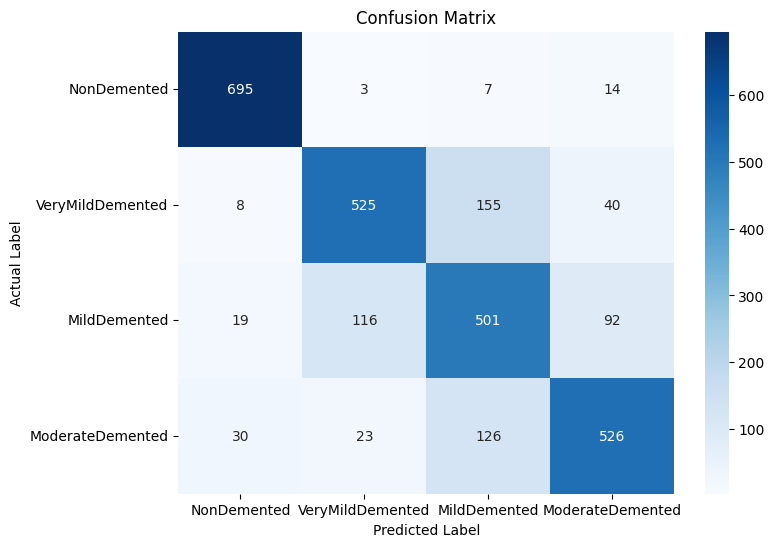

In [ ]:
# Compute confusion matrix
conf_matrix_xception = confusion_matrix(y_true_xception, y_pred_xception)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xception, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

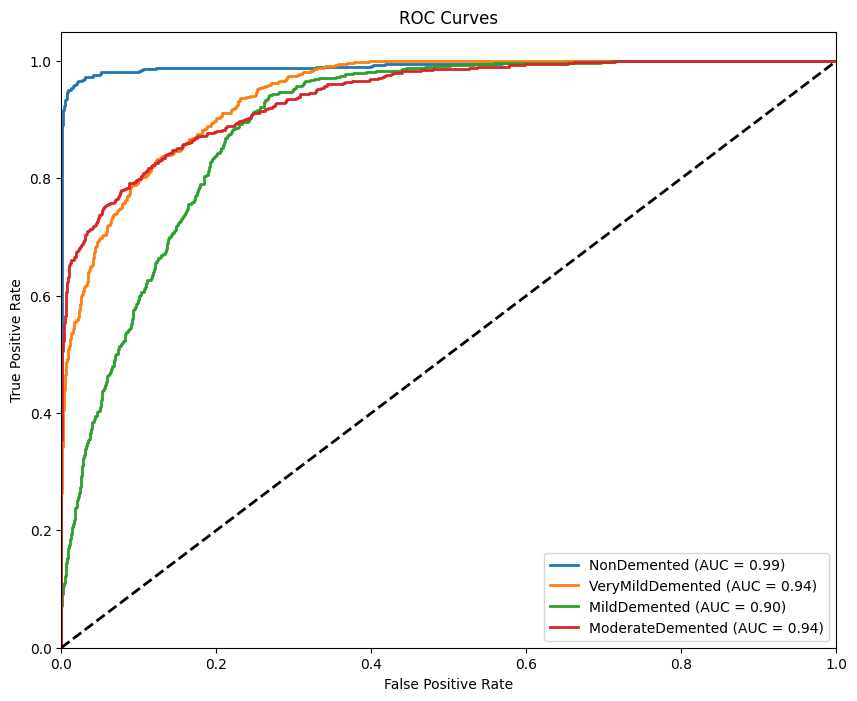

In [ ]:
# Binarize true labels for multi-class ROC computation
y_true_binarized_xception = label_binarize(y_true_xception, classes=range(len(class_names)))

plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_binarized_xception[:, i], y_pred_prob_xception[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.show()

90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step

Xception Model Classification Report with Specificity:
NonDemented:
  Precision: 0.92
  Recall: 0.97
  F1-Score: 0.94
  Specificity: 0.97
  Support: 719
VeryMildDemented:
  Precision: 0.79
  Recall: 0.72
  F1-Score: 0.75
  Specificity: 0.93
  Support: 728
MildDemented:
  Precision: 0.63
  Recall: 0.69
  F1-Score: 0.66
  Specificity: 0.87
  Support: 728
ModerateDemented:
  Precision: 0.78
  Recall: 0.75
  F1-Score: 0.76
  Specificity: 0.93
  Support: 705

Overall Weighted Average Metrics:
  Precision: 0.78
  Recall: 0.78
  F1-score: 0.78
  Support: 2880


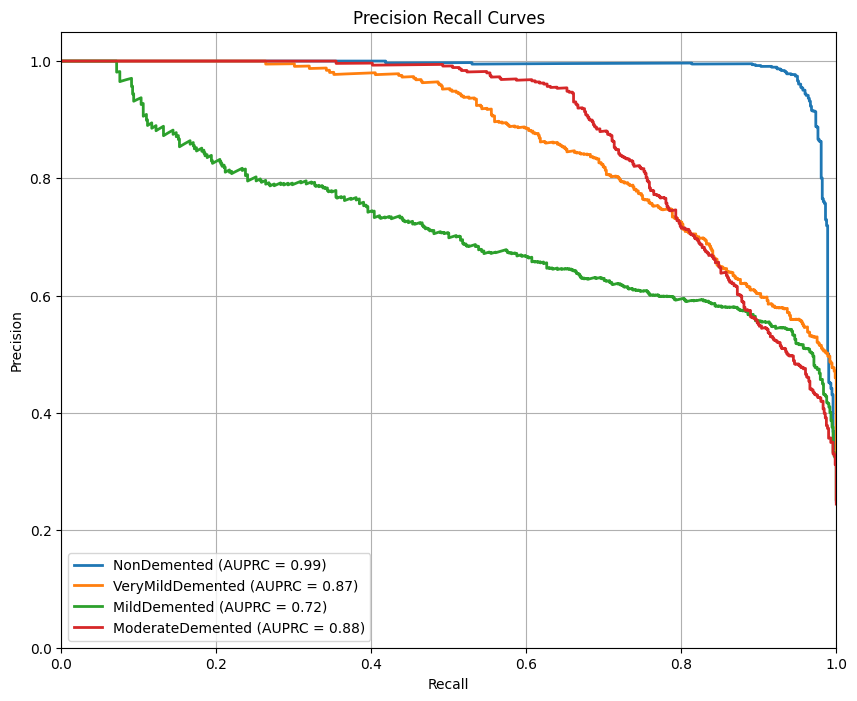

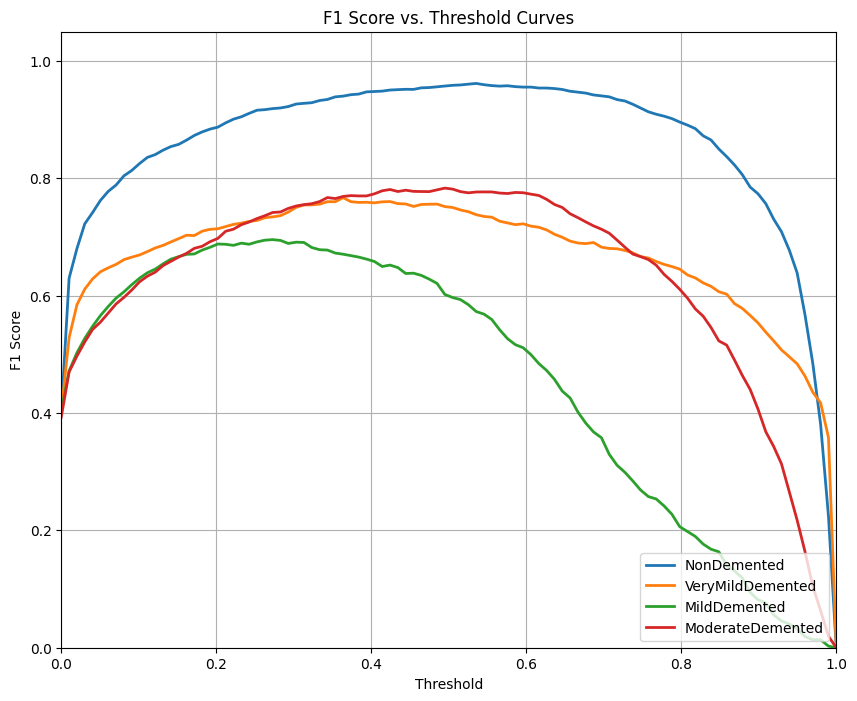

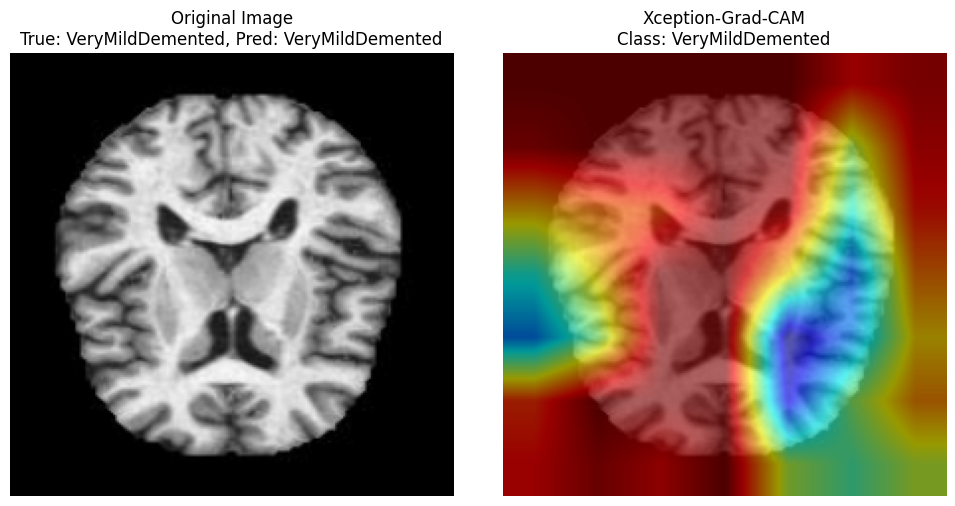

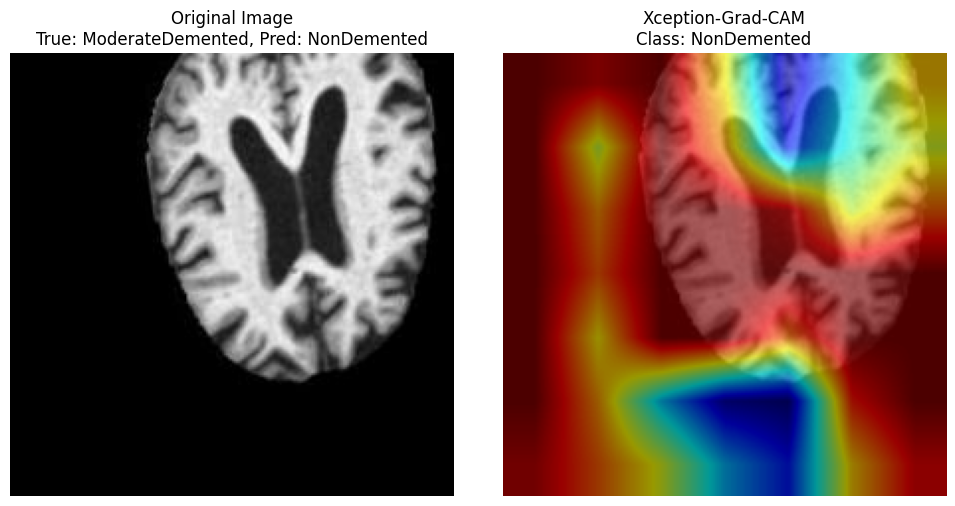

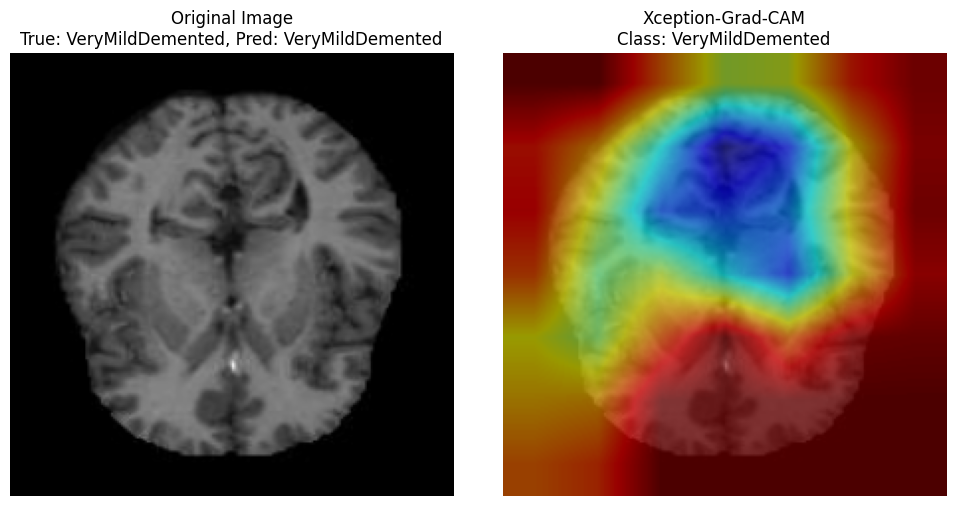

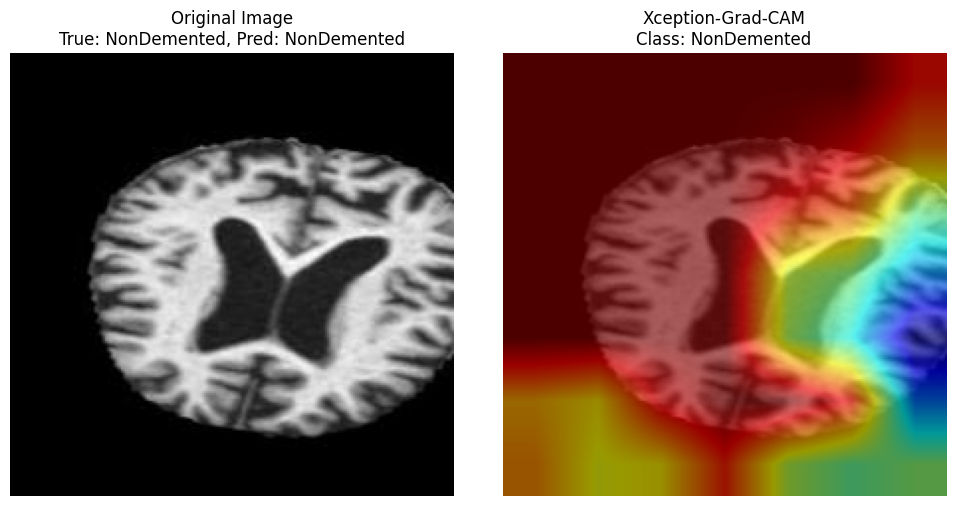

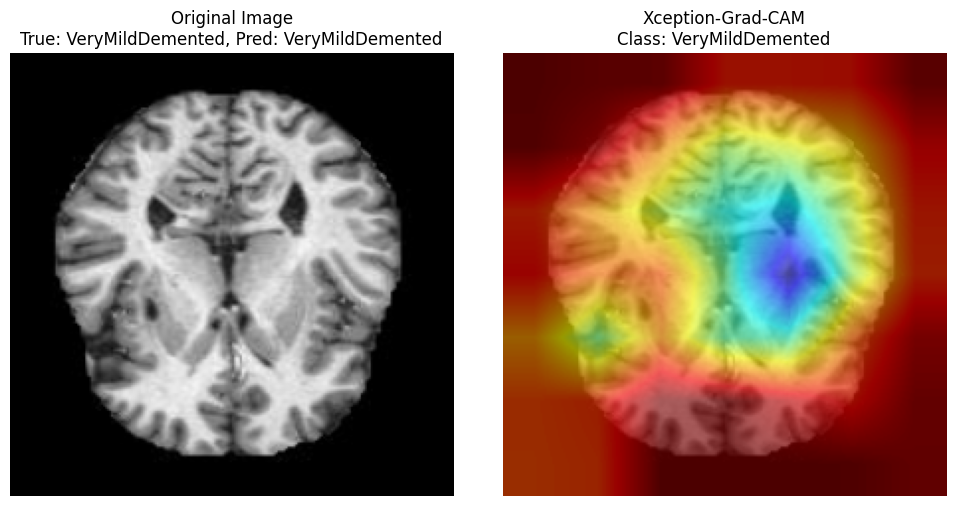

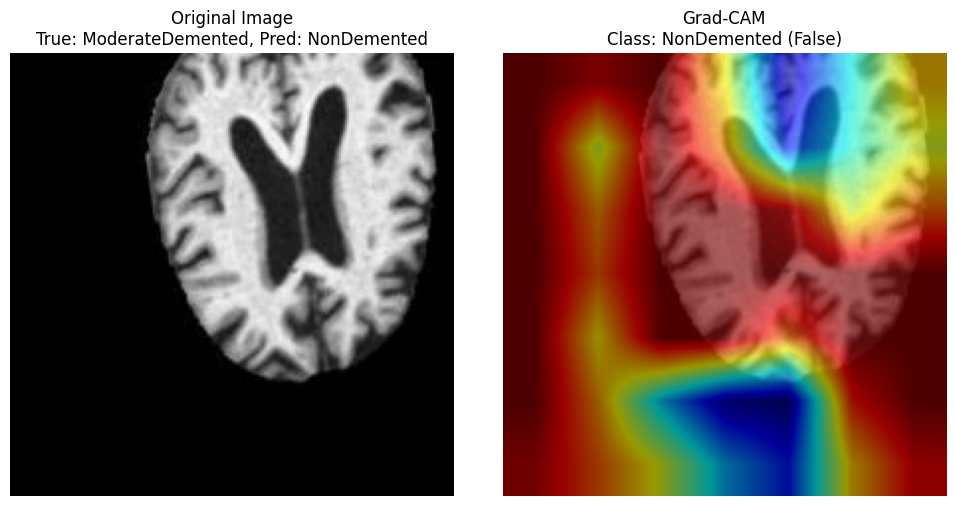

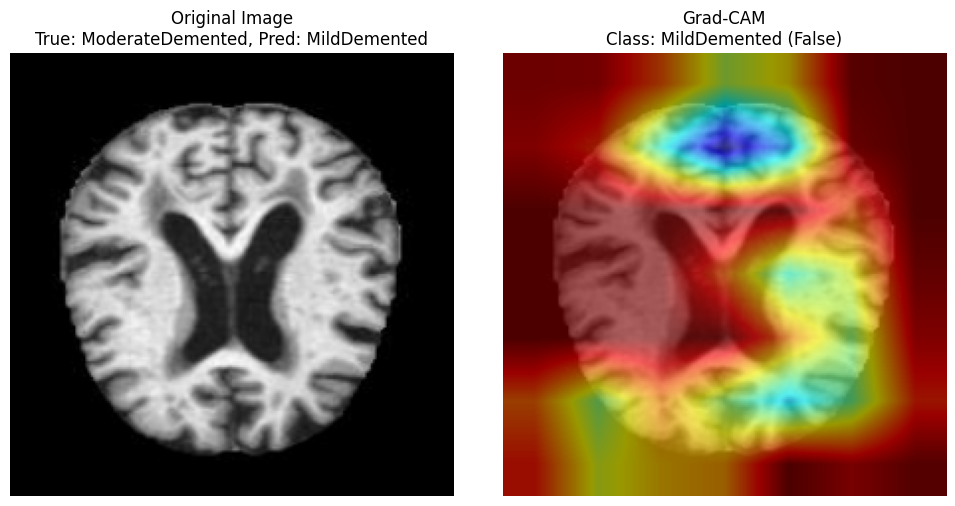

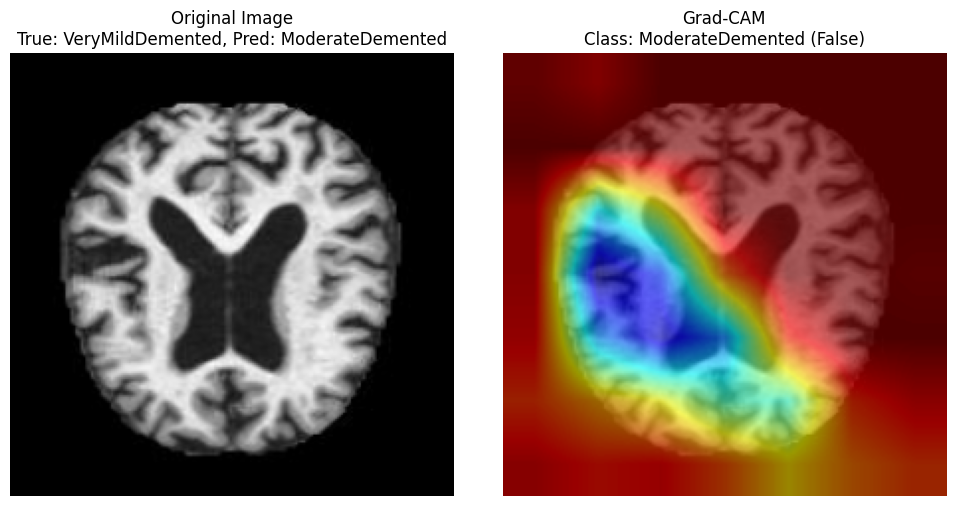

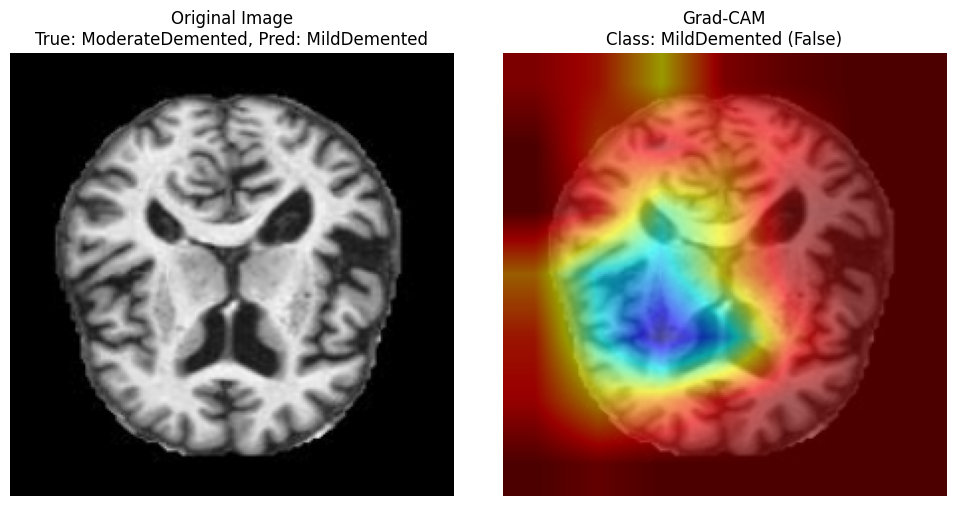

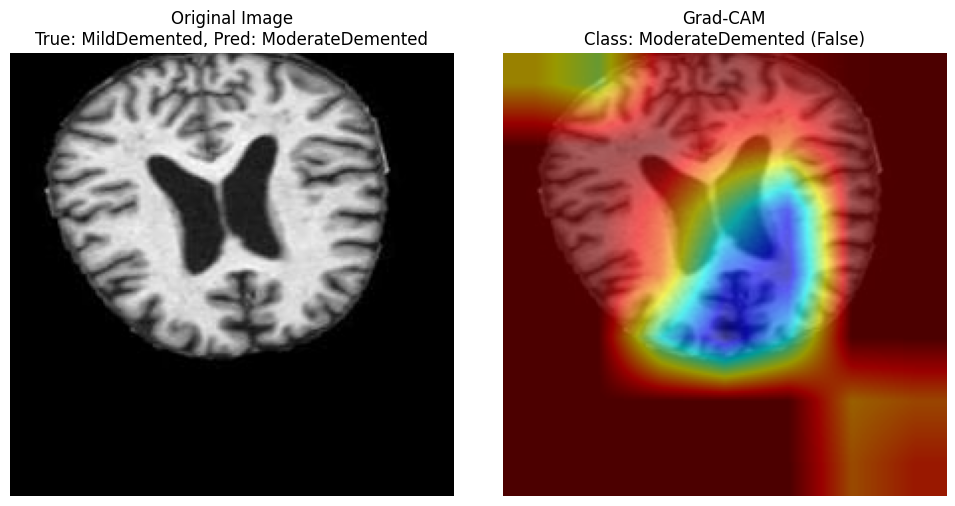

In [ ]:
# Assuming xception_model, val_ds, and class_names are defined
class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

# Generate predictions and true labels
y_pred_prob_xception = xception_model.predict(val_ds)  # Probability outputs
y_pred_xception = np.argmax(y_pred_prob_xception, axis=1)  # Convert to class labels
y_true_xception = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds])

# Custom function to calculate specificity for each class
def specificity_score(y_true, y_pred, class_idx):
    cm = confusion_matrix(y_true, y_pred)
    tn = np.sum(cm) - np.sum(cm[class_idx, :]) - np.sum(cm[:, class_idx]) + cm[class_idx, class_idx]
    fp = np.sum(cm[:, class_idx]) - cm[class_idx, class_idx]
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# 1. Classification Report with Specificity
print("\nXception Model Classification Report with Specificity:")
report = classification_report(y_true_xception, y_pred_xception, target_names=class_names, output_dict=True)
specificities = [specificity_score(y_true_xception, y_pred_xception, i) for i in range(len(class_names))]

for i, class_name in enumerate(class_names):
    class_report = report[class_name]
    print(f"{class_name}:")
    print(f"  Precision: {class_report['precision']:.2f}")
    print(f"  Recall: {class_report['recall']:.2f}")
    print(f"  F1-Score: {class_report['f1-score']:.2f}")
    print(f"  Specificity: {specificities[i]:.2f}")
    print(f"  Support: {class_report['support']}")

print("\nOverall Weighted Average Metrics:")
for metric in ['precision', 'recall', 'f1-score']:
    print(f"  {metric.capitalize()}: {report['weighted avg'][metric]:.2f}")
print(f"  Support: {report['weighted avg']['support']}")

# 2. Precision-Recall Curve
plt.figure(figsize=(10, 8))
y_true_binarized_xception = label_binarize(y_true_xception, classes=range(len(class_names)))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_true_binarized_xception[:, i], y_pred_prob_xception[:, i])
    auprc = auc(recall, precision)
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]} (AUPRC = {auprc:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curves")
plt.legend(loc="lower left")
plt.grid()
plt.savefig('/kaggle/working/xception_precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. F1 Score Curve
plt.figure(figsize=(10, 8))
thresholds = np.linspace(0, 1, 100)
for i in range(len(class_names)):
    f1_scores = [f1_score(y_true_binarized_xception[:, i], (y_pred_prob_xception[:, i] >= t).astype(int))
                 for t in thresholds]
    plt.plot(thresholds, f1_scores, lw=2, label=f"{class_names[i]}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold Curves")
plt.legend(loc="lower right")
plt.grid()
plt.savefig('/kaggle/working/xception_f1_score_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Grad-CAM Functions
def preprocess_image(img):
    if img.max() <= 1.0:
        img = img * 255.0
    elif img.min() < 0:
        img = (img + 1.0) * 127.5
    return np.clip(img, 0, 255).astype(np.uint8)

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap_max = tf.math.reduce_max(heatmap)
    heatmap = heatmap / (heatmap_max + 1e-10)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.6):
    img = preprocess_image(img)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * np.clip(heatmap, 0, 1))
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img * (1 - alpha)
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img

# Generate Grad-CAM images for all predictions
def generate_gradcam_images(model, val_ds, class_names, last_conv_layer_name='block14_sepconv2_act', num_images=5):
    import os
    output_dir = '/kaggle/working/gradcam_xception'
    os.makedirs(output_dir, exist_ok=True)

    class_indices = {name: idx for idx, name in enumerate(class_names)}
    img_count = 0

    for images, labels in val_ds:
        if img_count >= num_images:
            break

        images_np = images.numpy()
        labels_np = np.argmax(labels.numpy(), axis=1)

        for i in range(images_np.shape[0]):
            if img_count >= num_images:
                break

            img = images_np[i]
            true_label = labels_np[i]
            true_class = class_names[true_label]

            pred_probs = model.predict(images[i:i+1], verbose=0)
            pred_class_idx = np.argmax(pred_probs[0])
            pred_class = class_names[pred_class_idx]

            heatmap = get_gradcam_heatmap(model, images[i:i+1], last_conv_layer_name, pred_index=pred_class_idx)
            superimposed_img = overlay_gradcam(img, heatmap)

            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(preprocess_image(img))
            plt.title(f'Original Image\nTrue: {true_class}, Pred: {pred_class}')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(superimposed_img)
            plt.title(f'Xception-Grad-CAM\nClass: {pred_class}')
            plt.axis('off')

            plt.tight_layout()
            plt.savefig(f'{output_dir}/gradcam_image_{img_count+1}_true_{true_class}_pred_{pred_class}.png',
                       dpi=300, bbox_inches='tight')
            plt.show()

            img_count += 1

# Generate Grad-CAM images for false predictions
def generate_gradcam_false_predictions(model, val_ds, class_names, last_conv_layer_name='block14_sepconv2_act', num_images=5):
    import os
    output_dir = '/kaggle/working/gradcam_xception_false'
    os.makedirs(output_dir, exist_ok=True)

    class_indices = {name: idx for idx, name in enumerate(class_names)}
    img_count = 0

    for images, labels in val_ds:
        if img_count >= num_images:
            break

        images_np = images.numpy()
        labels_np = np.argmax(labels.numpy(), axis=1)

        for i in range(images_np.shape[0]):
            if img_count >= num_images:
                break

            img = images_np[i]
            true_label = labels_np[i]
            true_class = class_names[true_label]

            pred_probs = model.predict(images[i:i+1], verbose=0)
            pred_class_idx = np.argmax(pred_probs[0])
            pred_class = class_names[pred_class_idx]

            if true_class != pred_class:
                heatmap = get_gradcam_heatmap(model, images[i:i+1], last_conv_layer_name, pred_index=pred_class_idx)
                superimposed_img = overlay_gradcam(img, heatmap)

                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.imshow(preprocess_image(img))
                plt.title(f'Original Image\nTrue: {true_class}, Pred: {pred_class}')
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(superimposed_img)
                plt.title(f'Grad-CAM\nClass: {pred_class} (False)')
                plt.axis('off')

                plt.tight_layout()
                plt.savefig(f'{output_dir}/gradcam_false_{img_count+1}_true_{true_class}_pred_{pred_class}.png',
                           dpi=300, bbox_inches='tight')
                plt.show()

                img_count += 1

# Generate all plots and Grad-CAM images
generate_gradcam_images(xception_model, val_ds, class_names, last_conv_layer_name='block14_sepconv2_act', num_images=5)
generate_gradcam_false_predictions(xception_model, val_ds, class_names, last_conv_layer_name='block14_sepconv2_act', num_images=5)